# 04 — Inference & Grad-CAM

**But** : charger le meilleur checkpoint et effectuer des prédictions individuelles, avec interprétabilité Grad-CAM.

> Ce notebook est **totalement indépendant** — il recharge le modèle depuis le disque.

## 1. Setup

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/LAAFI_AI-main
except ImportError:
    pass

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

Mounted at /content/drive
/content/drive/MyDrive/LAAFI_AI-main


In [2]:
import datasets
datasets.logging.set_verbosity_error()

import numpy as np
import torch
import matplotlib.pyplot as plt

from laafi_ai.cli_train import set_seed
from laafi_ai.config import ExperimentConfig
from laafi_ai.data import PCamDataModule
from laafi_ai.gradcam import make_gradcam_overlay
from laafi_ai.inference import load_model_from_checkpoint
from laafi_ai.logging_utils import setup_logging
from laafi_ai.model import get_device
from laafi_ai.paths import resolve_project_paths

setup_logging()

## 2. Configuration et chargement du modèle

In [3]:
config = ExperimentConfig.from_yaml('configs/default.yaml')
config.output_dir = 'outputs_finetune_layer4'

set_seed(config.seed)
device = get_device(config.device)
paths = resolve_project_paths(config, project_root=PROJECT_ROOT)

BEST_CHECKPOINT = paths.checkpoint_dir / 'best_resnet50_pcam.pt'
model, loaded_config = load_model_from_checkpoint(BEST_CHECKPOINT, device)
print('Modèle chargé ✓')

2026-07-07 16:13:49,605 | INFO | laafi_ai.paths | Project root: /content/drive/MyDrive/LAAFI_AI-main
2026-07-07 16:13:49,606 | INFO | laafi_ai.paths | Output directory: /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 63.4MB/s]


2026-07-07 16:13:57,522 | INFO | laafi_ai.model | Freezing ResNet50 backbone
2026-07-07 16:13:57,534 | INFO | laafi_ai.model | Unfreezing ResNet50 layer4
Modèle chargé ✓


## 3. Charger quelques images du test set

In [4]:
data_module = PCamDataModule(config.data)
_, _, test_loader = data_module.dataloaders()

# Prendre un batch pour la démo
images, labels = next(iter(test_loader))
print(f'Batch de {images.shape[0]} images chargé.')

2026-07-07 16:13:57,727 | INFO | laafi_ai.data | Loading dataset 1aurent/PatchCamelyon
2026-07-07 16:14:01,811 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-07-07 16:14:01,876 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-07-07 16:14:01,923 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/1aurent/PatchCamelyon/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/README.md "HTTP/1.1 200 OK"
2026-07-07 16:14:01,974 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/1aurent/PatchCamelyon/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/README.md "HTTP/1.1 200 OK"


README.md:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

2026-07-07 16:14:02,070 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/PatchCamelyon.py "HTTP/1.1 404 Not Found"
2026-07-07 16:14:02,200 | INFO | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/1aurent/PatchCamelyon/1aurent/PatchCamelyon.py "HTTP/1.1 404 Not Found"
2026-07-07 16:14:02,301 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/datasets/1aurent/PatchCamelyon/revision/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab "HTTP/1.1 200 OK"
2026-07-07 16:14:02,414 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-07-07 16:14:02,710 | INFO | httpx | HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=1aurent/PatchCamelyon "HTTP/1.1 200 OK"
2026-07-07 16:14:02,822 | INFO | httpx | HTTP Request:

data/train-00000-of-00013-4717c3cf92578c(…):   0%|          | 0.00/471M [00:00<?, ?B/s]

2026-07-07 16:14:09,884 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/data/train-00001-of-00013-549914845b4273b1.parquet "HTTP/1.1 302 Found"


...

data/test-00001-of-00002-3bfa172e8818685(…):   0%|          | 0.00/375M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/262144 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Batch de 32 images chargé.


## 4. Prédictions sur le batch

In [5]:
model.eval()
with torch.no_grad():
    logits = model(images.to(device)).squeeze(1)
    probs = torch.sigmoid(logits).cpu().numpy()

threshold = config.training.decision_threshold
preds = (probs >= threshold).astype(int)

for i in range(min(8, len(probs))):
    label_str = 'Métastase' if labels[i] == 1 else 'Normal'
    pred_str = 'Métastase' if preds[i] == 1 else 'Normal'
    marker = '✓' if preds[i] == int(labels[i]) else '✗'
    print(f'  [{marker}] Image {i}: vrai={label_str}, prédit={pred_str} (p={probs[i]:.4f})')

  [✓] Image 0: vrai=Normal, prédit=Normal (p=0.0043)
  [✓] Image 1: vrai=Métastase, prédit=Métastase (p=0.9994)
  [✗] Image 2: vrai=Normal, prédit=Métastase (p=0.7668)
  [✓] Image 3: vrai=Métastase, prédit=Métastase (p=1.0000)
  [✗] Image 4: vrai=Métastase, prédit=Normal (p=0.0541)
  [✓] Image 5: vrai=Normal, prédit=Normal (p=0.3350)
  [✓] Image 6: vrai=Métastase, prédit=Métastase (p=0.7221)
  [✓] Image 7: vrai=Métastase, prédit=Métastase (p=0.5602)


## 5. Grad-CAM — Interprétabilité

Grad-CAM permet de voir *quelles régions de l'image* ont le plus influencé la prédiction du modèle.

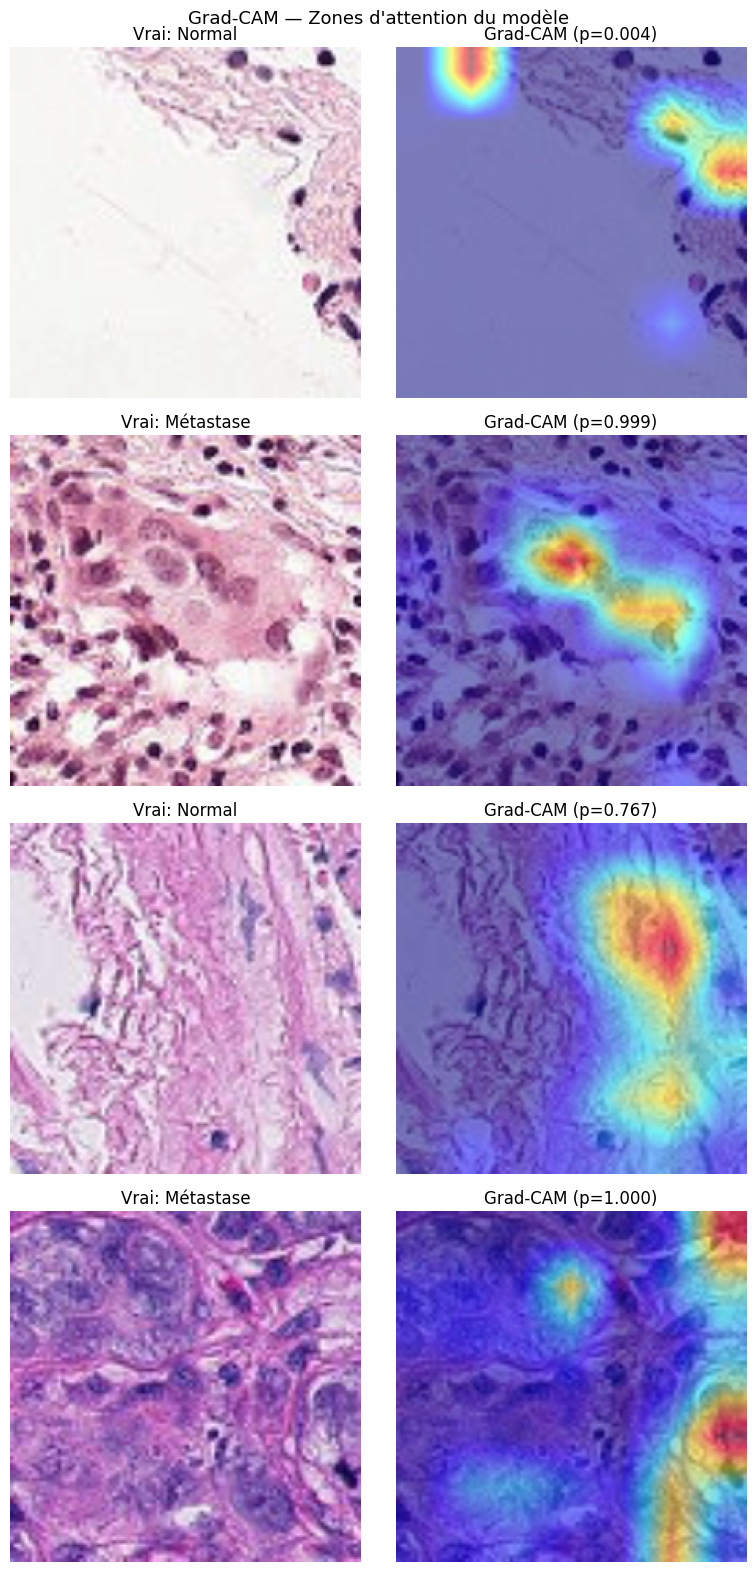

Sauvegardé dans /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4/figures/gradcam_samples.png


In [8]:
import sys
import subprocess
import pip
try:
    import pytorch_grad_cam
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'grad-cam'])
    import pytorch_grad_cam

# Couche cible pour Grad-CAM (dernier bloc convolutif de ResNet50)
target_layer = model.layer4[-1]

N_SAMPLES = min(4, len(images))
fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(8, 4 * N_SAMPLES))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(N_SAMPLES):
    # Image originale dé-normalisée
    img_np = images[i].permute(1, 2, 0).numpy()
    img_rgb = np.clip(img_np * std + mean, 0, 1)

    # Grad-CAM overlay
    overlay = make_gradcam_overlay(model, images[i], target_layer)

    label_str = 'Métastase' if labels[i] == 1 else 'Normal'
    pred_str = f'p={probs[i]:.3f}'

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f'Vrai: {label_str}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f'Grad-CAM ({pred_str})')
    axes[i, 1].axis('off')

plt.suptitle('Grad-CAM — Zones d\'attention du modèle', fontsize=13)
plt.tight_layout()
plt.savefig(paths.figures_dir / 'gradcam_samples.png', dpi=150)
plt.show()
print('Sauvegardé dans', paths.figures_dir / 'gradcam_samples.png')

---
**Fin du pipeline.**